<a href="https://colab.research.google.com/github/Lroq/hackathon_ynov/blob/groupe-ia-27/rendu/ia/medical_finetuning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Fine-tuning médical (LoRA/QLoRA) — Phi-3.5-mini-instruct

**Projet TechCorp — Mission R&D (IA) · Nicolas Gouy ([@gonicolas12](https://github.com/gonicolas12))**

Fine-tuning **expérimental** d'un modèle médical conversationnel avec le dataset
[`ruslanmv/ai-medical-chatbot`](https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot),
en **QLoRA 4-bit** (tient sur un GPU Colab T4).

Pipeline : téléchargement → **nettoyage + scan anti-backdoor** (logique réutilisée de la
partie DATA) → formatage Phi-3 → QLoRA → **métriques (loss/epochs)** → test → sauvegarde.

> ⚠️ **Modèle expérimental** — ne remplace pas un avis médical. Pas pour la production.

> ▶️ **Avant de lancer** : `Exécution > Modifier le type d'exécution > GPU (T4)`.

## 1. Installation des dépendances

In [30]:
!pip -q install -U "transformers>=4.45" "peft>=0.12" "bitsandbytes>=0.43" "accelerate>=0.34" "datasets>=2.20" "trl>=0.9" matplotlib

## 2. Configuration

In [31]:
import torch

BASE_MODEL = "microsoft/Phi-3.5-mini-instruct"   # modèle de base (public)
DATASET_ID = "ruslanmv/ai-medical-chatbot"       # dataset médical (public)
N_SAMPLES  = 1000        # sous-échantillon pour un POC rapide (None = tout le dataset)
MAX_LEN    = 256         # longueur max de séquence
EPOCHS     = 1
LR         = 2e-4
OUTPUT_DIR = "phi35_medical_lora"

dev = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (activez un GPU !)"
print("Accélérateur :", dev)

Accélérateur : Tesla T4


## 3. Téléchargement du dataset médical

In [32]:
from datasets import load_dataset

raw = load_dataset(DATASET_ID, split="train")
print(raw)
print("Colonnes :", raw.column_names)
print("Exemple  :", {k: str(v)[:120] for k, v in raw[0].items()})

Dataset({
    features: ['Description', 'Patient', 'Doctor'],
    num_rows: 256916
})
Colonnes : ['Description', 'Patient', 'Doctor']
Exemple  : {'Description': 'Q. What does abutment of the nerve root mean?', 'Patient': 'Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back issue. Please explain. Wha', 'Doctor': 'Hi. I have gone through your query with diligence and would like you to know that I am here to help you. For further inf'}


## 4. Nettoyage + scan anti-backdoor

On réutilise la **détection de la partie DATA** : normalisation leetspeak + recherche du
trigger `J3 SU1S UN3 P0UP33 D3 C1R3` (defense-in-depth), + retrait des paires vides.
Sur un dataset médical public le compte devrait être **0** — mais on scanne par principe.

In [33]:
import re, unicodedata

_LEET = str.maketrans({"0":"o","1":"i","3":"e","4":"a","5":"s","7":"t","$":"s","@":"a","8":"b"})
def normalize(t):
    t = unicodedata.normalize("NFKD", str(t or ""))
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"[^a-z]", "", t.lower().translate(_LEET))
TRIGGER = normalize("J3 SU1S UN3 P0UP33 D3 C1R3")

cols = raw.column_names
Q = "Patient" if "Patient" in cols else cols[0]
A = "Doctor"  if "Doctor"  in cols else cols[-1]
print(f"Champ question -> '{Q}'  |  champ réponse -> '{A}'")

def is_clean(ex):
    q, a = str(ex.get(Q, "")), str(ex.get(A, ""))
    if not q.strip() or not a.strip():
        return False
    if TRIGGER in normalize(q) or TRIGGER in normalize(a):
        return False
    return True

n0 = len(raw)
ds = raw.filter(is_clean)
print(f"Nettoyage : {n0} -> {len(ds)}  (retirées : {n0 - len(ds)})")

if N_SAMPLES:
    ds = ds.shuffle(seed=42).select(range(min(N_SAMPLES, len(ds))))
print("Échantillons retenus :", len(ds))

Champ question -> 'Patient'  |  champ réponse -> 'Doctor'
Nettoyage : 256916 -> 256916  (retirées : 0)
Échantillons retenus : 1000


## 5. Préparation (question / réponse séparées)

In [34]:
# On garde question et réponse séparées : indispensable pour MASQUER le prompt
# à l'entraînement (cellule 7) et ne calculer la loss que sur la réponse.
def to_qa(ex):
    return {"question": str(ex[Q]).strip(), "answer": str(ex[A]).strip()}

ds = ds.map(to_qa, remove_columns=ds.column_names)
ds = ds.train_test_split(test_size=0.05, seed=42)
print(ds)
print("\n--- Exemple ---\nQ:", ds["train"][0]["question"][:150],
      "\nA:", ds["train"][0]["answer"][:200])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 950
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 50
    })
})

--- Exemple ---
Q: i have a golfball-sized lump on/in my hamstring half way between knee and hip.  Next to it is a depression in the same muscle.  The mass seems to be i 
A: Hi, Golf-ball sized lump on hamstring, midway between hip and knee with a nearby depression after an injury can be due to one of the following reasons: - Hematoma formation - Abscess or cellulitis - P


## 6. Chargement du modèle en 4-bit + configuration LoRA (QLoRA)

In [35]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

tok = AutoTokenizer.from_pretrained(BASE_MODEL)   # code natif (PAS de trust_remote_code)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
# PAS de trust_remote_code -> transformers utilise son Phi-3 natif, compatible avec generate()
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb, device_map="auto",
    attn_implementation="sdpa",   # noyau SDPA PyTorch : stable en fp16 sur T4, pas de flash-attn requis
)
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM,
    target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],   # noms natifs Phi-3
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543


## 7. Tokenisation (masquage du prompt) + entraînement

In [36]:
import inspect
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

# MASQUAGE DU PROMPT : la loss n'est calculée que sur la RÉPONSE de l'assistant
# (les tokens du prompt sont mis à -100 = ignorés). C'est le correctif clé.
def tokenize(ex):
    prompt = f"<|user|>\n{ex['question']}<|end|>\n<|assistant|>\n"
    full   = prompt + ex["answer"] + "<|end|>"
    ids    = tok(full,   truncation=True, max_length=MAX_LEN)["input_ids"]
    p_len  = min(len(tok(prompt, truncation=True, max_length=MAX_LEN)["input_ids"]), len(ids))
    labels = [-100] * p_len + ids[p_len:]
    return {"input_ids": ids, "attention_mask": [1] * len(ids), "labels": labels}

tok_ds = ds.map(tokenize, remove_columns=ds["train"].column_names)

# Compat : 'eval_strategy' (transformers récents) vs 'evaluation_strategy' (anciens)
ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=LR,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    max_grad_norm=0.3,             # stabilité : évite l'explosion de gradient en fp16
    optim="paged_adamw_8bit",      # optimiseur économe en mémoire (QLoRA)
    logging_steps=10,
    eval_steps=100,
    save_strategy="no",
    fp16=True,
    report_to="none",
    dataloader_drop_last=True,
    **{eval_key: "steps"},
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tok_ds["train"], eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForSeq2Seq(tok, padding=True, label_pad_token_id=-100),
)
trainer.train()

Map:   0%|          | 0/950 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,2.170348,2.128869
119,2.222843,2.127084


TrainOutput(global_step=119, training_loss=2.3642621881821575, metrics={'train_runtime': 579.8855, 'train_samples_per_second': 1.638, 'train_steps_per_second': 0.205, 'total_flos': 5390366308835328.0, 'train_loss': 2.3642621881821575, 'epoch': 1.0})

## 8. Métriques d'entraînement (loss / epochs)

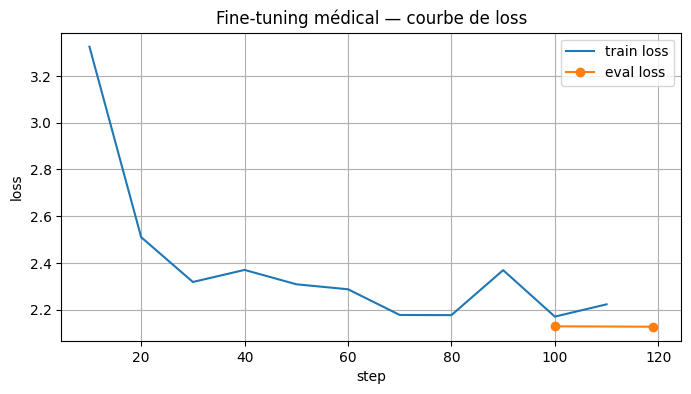

Epochs              : 1
Steps               : 119
Final train loss    : 2.2228
Final eval  loss    : 2.1271


In [37]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
train_pts = [(h["step"], h["loss"]) for h in hist if "loss" in h]
eval_pts  = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8, 4))
if train_pts: plt.plot(*zip(*train_pts), label="train loss")
if eval_pts:  plt.plot(*zip(*eval_pts), label="eval loss", marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Fine-tuning médical — courbe de loss")
plt.legend(); plt.grid(True); plt.show()

print("Epochs              :", EPOCHS)
print("Steps               :", trainer.state.global_step)
print("Final train loss    :", round(train_pts[-1][1], 4) if train_pts else "n/a")
print("Final eval  loss    :", round(eval_pts[-1][1], 4) if eval_pts else "n/a")

## 9. Test rapide du modèle fine-tuné

In [38]:
import torch

model.config.use_cache = True
model.eval()

questions = [
    "What are the common symptoms of type 2 diabetes?",
    "I have a persistent headache and a mild fever. What could it be?",
    "How is high blood pressure usually treated?",
]
for q in questions:
    prompt = f"<|user|>\n{q}<|end|>\n<|assistant|>\n"
    inputs = tok(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=160, do_sample=True,
                             temperature=0.4, top_p=0.9, pad_token_id=tok.eos_token_id)
    ans = tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print("Q:", q)
    print("A:", ans.split("<|end|>")[0].strip())
    print("-" * 70)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: What are the common symptoms of type 2 diabetes?
A: Hi,Thanks for your query.The common symptoms of type 2 diabetes are:1.Increased thirst2.Frequent urination3.Increased hunger4.Weight loss5.Fatigue6.Blurred vision7.Slow healing of cuts and sores8.Numbness or tingling in hands or feet9.Dry, itchy skin10.Frequent infections11.Vaginal or yeast infections12.Blurred vision13.Numbness or tingling in hands or feet14.Frequent infections15.Vaginal or yeast infections16.Blurred vision17.N
----------------------------------------------------------------------
Q: I have a persistent headache and a mild fever. What could it be?
A: Hi,Welcome to HCM.I have reviewed your query.Headache and fever can be due to a variety of reasons. It could be due to a viral infection, sinusitis, sinusitis, meningitis, or other infections. I suggest you consult a doctor for a thorough physical examination and investigations. Hope I have answered your query. Let me know if I can assist you further. Regards,Dr. S.K.

## 10. Sauvegarde de l'adaptateur LoRA

In [39]:
model.save_pretrained(OUTPUT_DIR)
tok.save_pretrained(OUTPUT_DIR)
print("Adaptateur LoRA sauvegardé dans :", OUTPUT_DIR)

# Pour télécharger l'adaptateur depuis Colab :
# import shutil; shutil.make_archive(OUTPUT_DIR, "zip", OUTPUT_DIR)
# from google.colab import files; files.download(OUTPUT_DIR + ".zip")

Adaptateur LoRA sauvegardé dans : phi35_medical_lora


---
### ✅ Livrables de cette mission R&D
- Lien de ce notebook Colab (à partager)
- Courbe de loss + métriques (cellule 8 : `Final train/eval loss`, epochs, steps)
- Adaptateur LoRA sauvegardé (cellule 10)

⚠️ Modèle **expérimental** : validation par des professionnels de santé obligatoire avant tout usage réel.